### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
%pip install pandas matplotlib seaborn numpy

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached numpy-2.4.6-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached numpy-2.4.6-cp314-cp314-w


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Install Required Libraries

%pip install command is used to run it in any Python Notebook Environment

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

Importing Required Libraries to use in the project

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.

In [3]:
data = pd.read_csv('data/coupons.csv')

Load the dataset into a pandas DataFrame named 'data' from the csv file located at 'data/coupons.csv'

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


To get a quick look at the data for the first 5 rows

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

There are 12,684 rows and 26 columns in the dataset. Data Types are string and integer.

In [6]:
data.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684.000000,12684.000000,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
mean,63.301798,0.414144,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,19.154486,0.492593,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


Describe the dataset to get statistical summary of the numeric columns in the dataset

Count shows all numeric fields have data populated for all rows

2. Investigate the dataset for missing or problematic data.

In [7]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

Analyze the dataset for missing values

The coulmn 'car' has 12,576 null values

The coulmn 'Bar' has 107 null values

The coulmn 'CoffeeHouse' has 217 null values

The coulmn 'CarryAway' has 151 null values

The coulmn 'RestaurantLessThan20' has 130 null values

The coulmn 'Restaurant20To50' has 189 null values

In [8]:
print(f"Number of duplicated rows: {data.duplicated().sum()}")
data[data.duplicated()]

Number of duplicated rows: 74


,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
4192,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,less1,less1,1,1,1,0,1,1
4236,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Male,26,Single,...,gt8,gt8,4~8,less1,1,1,1,0,1,1
4280,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,26,Single,...,never,4~8,1~3,less1,1,1,1,0,1,1
4324,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,46,Single,...,never,4~8,1~3,1~3,1,1,1,0,1,1
4409,Work,Alone,Sunny,80,7AM,Carry out & Take away,1d,Female,21,Single,...,never,less1,1~3,never,1,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8511,Home,Alone,Sunny,80,6PM,Bar,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,0,0,1,0,1
8512,Home,Partner,Sunny,30,10PM,Carry out & Take away,2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,0,0,1,1
8513,Work,Alone,Rainy,55,7AM,Restaurant(<20),2h,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0
8515,Work,Alone,Snowy,30,7AM,Restaurant(20-50),1d,Male,46,Married partner,...,1~3,1~3,less1,1~3,1,1,1,0,1,0


Checking for duplicate rows in the dataset

There are 74 rows duplicated in the dataset

3. Decide what to do about your missing data -- drop, replace, other...

In [9]:
data.fillna('Unknown', inplace=True)

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12679,Home,Partner,Rainy,55,6PM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,1
12680,Work,Alone,Rainy,55,7AM,Carry out & Take away,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,0,1,1
12681,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12682,Work,Alone,Snowy,30,7AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,1,0,1,0


Columns 'car', 'Bar', 'CoffeeHouse', 'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50' are Categorical columns and they contain null values.

'Unknown' literal text is not present in the original dataset.

So they are filled by replacing the null (NaN) values with 'Unknown' category.

Resulting DataFrame will be overwritten using inplace=True parameter.

In [10]:
print(f"Shape of the dataset before removing duplicates: {data.shape}")

data.drop_duplicates(subset=None, keep='first', inplace=True, ignore_index=True)

print(f"Shape of the dataset after removing duplicates: {data.shape}")

Shape of the dataset before removing duplicates: (12684, 26)
Shape of the dataset after removing duplicates: (12610, 26)


Print the Shape of the dataset before and after removing duplicates.

Remove duplicate rows from the dataset that are duplicate for all the columns, keeping only the first occurrence in the duplicate set

inplace=True means that the changes will be made directly in the original DataFrame 'data'

ignore_index=True means that the row labels (or index) will be re-assigned from 0,1,2,3...n

74 rows are deleted as part of De-Dup. Original rows were 12,684. After De-Dup, rows count is 12,610.

In [11]:
data.info()
data.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 12610 entries, 0 to 12609
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12610 non-null  str  
 1   passanger             12610 non-null  str  
 2   weather               12610 non-null  str  
 3   temperature           12610 non-null  int64
 4   time                  12610 non-null  str  
 5   coupon                12610 non-null  str  
 6   expiration            12610 non-null  str  
 7   gender                12610 non-null  str  
 8   age                   12610 non-null  str  
 9   maritalStatus         12610 non-null  str  
 10  has_children          12610 non-null  int64
 11  education             12610 non-null  str  
 12  occupation            12610 non-null  str  
 13  income                12610 non-null  str  
 14  car                   12610 non-null  str  
 15  Bar                   12610 non-null  str  
 16  CoffeeHouse    

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

Analyze the dataset for missing values again after cleansing. There are no missing values now.

4. What proportion of the total observations chose to accept the coupon?



In [12]:
total_customers = data.shape[0]
print(f"Total Customers: {total_customers}")
total_coupon_accepted_customers = data.query('Y == 1').shape[0]
print(f"Total Coupon Accepted Customers: {total_coupon_accepted_customers}")
coupon_accepted_customers_ratio = total_coupon_accepted_customers / total_customers
print(f"Coupon Accepted Customers Ratio: {coupon_accepted_customers_ratio:.2%}")

Total Customers: 12610
Total Coupon Accepted Customers: 7157
Coupon Accepted Customers Ratio: 56.76%


Coupon Accepted Customers Ratio is Coupon Accepted Customers divided by the Total Customers

5. Use a bar plot to visualize the `coupon` column.

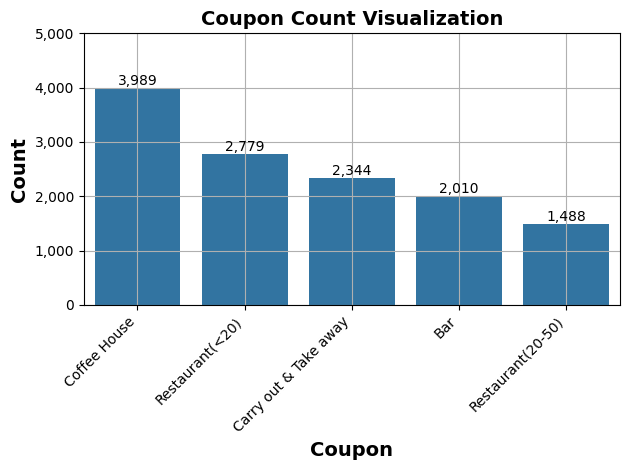

In [13]:
coupon_count = data['coupon'].value_counts()
ax = sns.barplot(x=coupon_count.index, y=coupon_count.values)
plt.title("Coupon Count Visualization", fontsize=14, fontweight="bold")
plt.xlabel("Coupon", fontsize=14, fontweight="bold")
plt.ylabel("Count", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha='right')
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
ax.set_ylim(0, 5000)
plt.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter('{x:,.0f}')
ax.grid(True)
plt.tight_layout()

This Seaborn Bar plot tells the Counts (Y Axis) for Each Coupon (X Axis)

6. Use a histogram to visualize the temperature column.

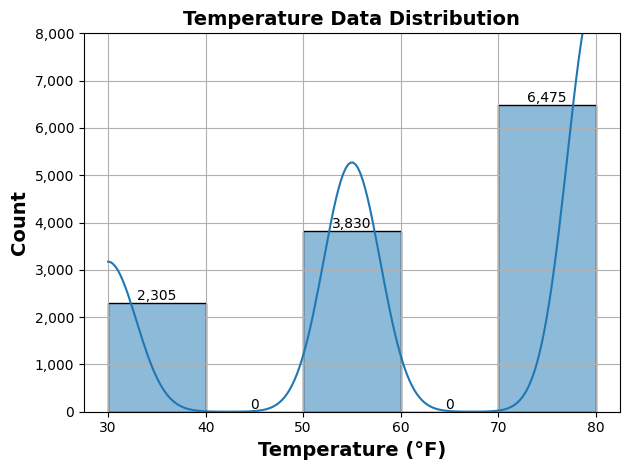

In [14]:
ax = sns.histplot(x=data['temperature'], bins=5, kde=True)
plt.title("Temperature Data Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Temperature (°F)", fontsize=14, fontweight="bold")
plt.ylabel("Count", fontsize=14, fontweight="bold")
ax.bar_label(ax.containers[0], fmt='{:,.0f}')
ax.set_ylim(0, 8000)
plt.ticklabel_format(style='plain', axis='y')
ax.yaxis.set_major_formatter('{x:,.0f}')
ax.grid(True)
plt.tight_layout()

This Seaborn Histogram plot tells the Counts (Y Axis) for Temperature Data Distribution (X Axis)
It also plots the KDE (Key Density Estimation) by plotting a smooth distribution curve

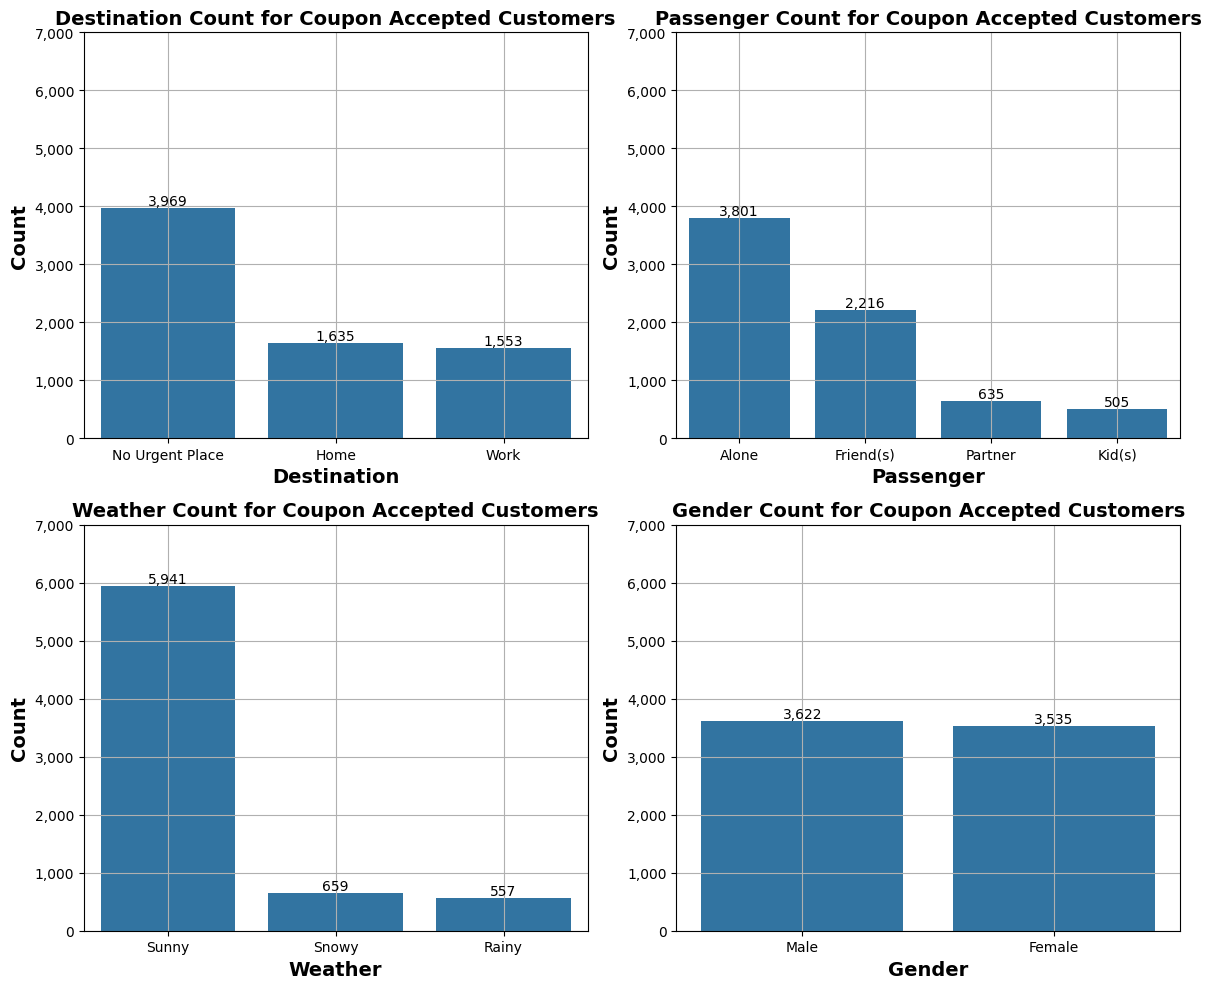

In [15]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

destination_count = data.query("Y==1")['destination'].value_counts()
sns.barplot(x=destination_count.index, y=destination_count.values, ax=axs[0,0])
axs[0,0].set_title("Destination Count for Coupon Accepted Customers", fontsize=14, fontweight="bold")
axs[0,0].set_xlabel("Destination", fontsize=14, fontweight="bold")
axs[0,0].set_ylabel("Count", fontsize=14, fontweight="bold")
axs[0,0].bar_label(axs[0,0].containers[0], fmt='{:,.0f}')
axs[0,0].set_ylim(0, 7000)
plt.ticklabel_format(style='plain', axis='y')
axs[0,0].yaxis.set_major_formatter('{x:,.0f}')
axs[0,0].grid(True)

passanger_count = data.query("Y==1")['passanger'].value_counts()
sns.barplot(x=passanger_count.index, y=passanger_count.values, ax=axs[0,1])
axs[0,1].set_title("Passenger Count for Coupon Accepted Customers", fontsize=14, fontweight="bold")
axs[0,1].set_xlabel("Passenger", fontsize=14, fontweight="bold")
axs[0,1].set_ylabel("Count", fontsize=14, fontweight="bold")
axs[0,1].bar_label(axs[0,1].containers[0], fmt='{:,.0f}')
axs[0,1].set_ylim(0, 7000)
plt.ticklabel_format(style='plain', axis='y')
axs[0,1].yaxis.set_major_formatter('{x:,.0f}')
axs[0,1].grid(True)

weather_count = data.query("Y==1")['weather'].value_counts()
sns.barplot(x=weather_count.index, y=weather_count.values, ax=axs[1,0])
axs[1,0].set_title("Weather Count for Coupon Accepted Customers", fontsize=14, fontweight="bold")
axs[1,0].set_xlabel("Weather", fontsize=14, fontweight="bold")
axs[1,0].set_ylabel("Count", fontsize=14, fontweight="bold")
axs[1,0].bar_label(axs[1,0].containers[0], fmt='{:,.0f}')
axs[1,0].set_ylim(0, 7000)
plt.ticklabel_format(style='plain', axis='y')
axs[1,0].yaxis.set_major_formatter('{x:,.0f}')
axs[1,0].grid(True)

gender_count = data.query("Y==1")['gender'].value_counts()
sns.barplot(x=gender_count.index, y=gender_count.values, ax=axs[1,1])
axs[1,1].set_title("Gender Count for Coupon Accepted Customers", fontsize=14, fontweight="bold")
axs[1,1].set_xlabel("Gender", fontsize=14, fontweight="bold")
axs[1,1].set_ylabel("Count", fontsize=14, fontweight="bold")
axs[1,1].bar_label(axs[1,1].containers[0], fmt='{:,.0f}')
axs[1,1].set_ylim(0, 7000)
plt.ticklabel_format(style='plain', axis='y')
axs[1,1].yaxis.set_major_formatter('{x:,.0f}')
axs[1,1].grid(True)

plt.tight_layout()

This is a Bonus Bar Sub Plot that plots 4 Sub Plots

First subplot: Coupons Accepted Customers by Destination - Customers who are not going to any Urgent Place, accept more coupons

Second subplot: Coupons Accepted Customers by Passenger - Customers who travel Alone, accept more coupons

Third subplot: Coupons Accepted Customers by Weather - When the Weather is Sunny, Customers accept more coupons

Fourth subplot: Coupons Accepted Customers by Gender - Both Male and Female accept almost similar number of coupons

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [16]:
bar_data = data.query("coupon == 'Bar'")
bar_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12589,No Urgent Place,Friend(s),Sunny,80,10PM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12590,No Urgent Place,Friend(s),Sunny,55,10PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12593,No Urgent Place,Alone,Rainy,55,10AM,Bar,1d,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0
12596,No Urgent Place,Partner,Rainy,55,6PM,Bar,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


There are total 2,010 Bar Coupons issued.

2. What proportion of bar coupons were accepted?


In [17]:
total_bar_coupons = bar_data.shape[0]
print(f"Total Bar Coupons: {total_bar_coupons}")
total_bar_coupons_accepted = bar_data.query('Y == 1').shape[0]
print(f"Total Bar Coupons Accepted: {total_bar_coupons_accepted}")
bar_coupon_accepted_ratio = total_bar_coupons_accepted / total_bar_coupons
print(f"Bar Coupons Accepted Ratio: {bar_coupon_accepted_ratio:.2%}")

Total Bar Coupons: 2010
Total Bar Coupons Accepted: 824
Bar Coupons Accepted Ratio: 41.00%


41% Bar Coupons are accepted.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [18]:
print(bar_data.query('Y == 1')['Bar'].value_counts())
total_bar_coupon_accepted_lt_3 = bar_data.query('Y == 1 and Bar in ["never","less1","1~3"]').shape[0]
total_bar_coupon_accepted_gt_3 = bar_data.query('Y == 1 and Bar in ["gt8","4~8"]').shape[0]
print(f"Total Bar Coupons Accepted by Customers who went to a bar 3 or fewer times a month: {total_bar_coupon_accepted_lt_3}")
print(f"Total Bar Coupons Accepted by Customers who went to a bar more than 3 times a month: {total_bar_coupon_accepted_gt_3}")
print(f"Bar Coupons Accepted Ratio between less than 3 visits and greater than 3 visits: {total_bar_coupon_accepted_lt_3 / total_bar_coupon_accepted_gt_3:.2%}")

Bar
1~3        257
less1      250
never      156
4~8        117
gt8         36
Unknown      8
Name: count, dtype: int64
Total Bar Coupons Accepted by Customers who went to a bar 3 or fewer times a month: 663
Total Bar Coupons Accepted by Customers who went to a bar more than 3 times a month: 153
Bar Coupons Accepted Ratio between less than 3 visits and greater than 3 visits: 433.33%


Distinct values for 'Bar' column are ['never', 'less1', '1~3', 'gt8', 'Unknown', '4~8']

Value 'Unknown' are not considered since we don't know about their Bar visits.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [19]:
total_bar_coupon_accepted = bar_data.query('Y == 1').shape[0]
total_bar_coupon_accepted_ge_1_and_age_gt_25 = bar_data.query('Y == 1 and Bar in ["1~3","gt8","4~8"] and age in ["26","31","36","41","46","50plus"]').shape[0]
total_bar_coupon_accepted_lt_1_or_age_le_25 = total_bar_coupon_accepted - total_bar_coupon_accepted_ge_1_and_age_gt_25
print(f"Total Bar Coupons Accepted Customers: {total_bar_coupon_accepted}")
print(f"Total Bar Coupons Accepted Customers who went to a bar 1 or more times a month and Age over 25: {total_bar_coupon_accepted_ge_1_and_age_gt_25}")
print(f"Total Bar Coupons Accepted Customers who went to a bar less than 1 time a month or Age less than equal to 25: {total_bar_coupon_accepted_lt_1_or_age_le_25}")

Total Bar Coupons Accepted Customers: 824
Total Bar Coupons Accepted Customers who went to a bar 1 or more times a month and Age over 25: 292
Total Bar Coupons Accepted Customers who went to a bar less than 1 time a month or Age less than equal to 25: 532


Yes. Customers who visit bar more than once a month and are over the age of 25 are 292, which is significantly less than all others count of 532.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [20]:
total_bar_coupon_accepted = bar_data.query('Y == 1').shape[0]
total_bar_coupon_accepted_ge_1_and_passanger_not_kid_and_occupation_not_forestry = bar_data.query('Y == 1 and Bar in ["1~3","gt8","4~8"] and passanger not in ["Kid(s)"] and occupation not in ["Farming Fishing & Forestry"]').shape[0]
total_bar_coupon_accepted_lt_1_or_passanger_kid_or_occupation_forestry = total_bar_coupon_accepted - total_bar_coupon_accepted_ge_1_and_passanger_not_kid_and_occupation_not_forestry
print(f"Total Bar Coupons Accepted Customers: {total_bar_coupon_accepted}")
print(f"Total Bar Coupons Accepted Customers who went to a bar 1 or more times a month and Passenger not Kids and Occupation not Forestry: {total_bar_coupon_accepted_ge_1_and_passanger_not_kid_and_occupation_not_forestry}")
print(f"Total Bar Coupons Accepted Customers who went to a bar less than 1 time a month or Passenger are Kids or Occupation is Forestry: {total_bar_coupon_accepted_lt_1_or_passanger_kid_or_occupation_forestry}")

Total Bar Coupons Accepted Customers: 824
Total Bar Coupons Accepted Customers who went to a bar 1 or more times a month and Passenger not Kids and Occupation not Forestry: 393
Total Bar Coupons Accepted Customers who went to a bar less than 1 time a month or Passenger are Kids or Occupation is Forestry: 431


Customers who visit bar more than once a month and passengers are not kids and occupation is Forestry count is around same as all others.


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [21]:
total_bar_coupon_accepted = bar_data.query('Y == 1').shape[0]
total_bar_coupon_accepted_complex_condition = bar_data.query('Y == 1 and ((Bar in ["1~3","gt8","4~8"] and passanger not in ["Kid(s)"] and maritalStatus not in ["Widowed"]) or (Bar in ["1~3","gt8","4~8"] and age in ["21","26","below21"]) or (RestaurantLessThan20 in ["4~8","gt8"] and income in ["Less than $12500","$12500 - $24999","$25000 - $37499","$37500 - $49999"]))').shape[0]
total_bar_coupon_accepted_all_others = total_bar_coupon_accepted - total_bar_coupon_accepted_complex_condition
print(f"Total Bar Coupons Accepted Customers: {total_bar_coupon_accepted}")
print(f"Total Bar Coupons Accepted Customers with Complex Conditions: {total_bar_coupon_accepted_complex_condition}")
print(f"Total Bar Coupons Accepted Customers opposite of Complex Conditions : {total_bar_coupon_accepted_all_others}")

Total Bar Coupons Accepted Customers: 824
Total Bar Coupons Accepted Customers with Complex Conditions: 457
Total Bar Coupons Accepted Customers opposite of Complex Conditions : 367


Total Bar Coupons Accepted Customers with Complex Conditions are higher than all others.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Total Bar Coupons: 2010

Total Bar Coupons Accepted: 824

Bar Coupons Accepted Ratio: 41.00%


Total Bar Coupons Accepted by Customers who went to a bar 3 or fewer times a month: 663

Total Bar Coupons Accepted by Customers who went to a bar more than 3 times a month: 153

Bar Coupons Accepted Ratio between less than 3 visits and greater than 3 visits: 433.33%


Total Bar Coupons Accepted Customers: 824

Total Bar Coupons Accepted Customers who went to a bar 1 or more times a month and Age over 25: 292

Total Bar Coupons Accepted Customers who went to a bar less than 1 time a month or Age less than equal to 25: 532


Total Bar Coupons Accepted Customers: 824

Total Bar Coupons Accepted Customers who went to a bar 1 or more times a month and Passenger not Kids and Occupation not Forestry: 393

Total Bar Coupons Accepted Customers who went to a bar less than 1 time a month or Passenger are Kids or Occupation is Forestry: 431


Total Bar Coupons Accepted Customers: 824

Total Bar Coupons Accepted Customers with Complex Conditions: 457

Total Bar Coupons Accepted Customers opposite of Complex Conditions : 367

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [22]:
coffee_house_data = data.query("coupon == 'Coffee House'")
coffee_house_data

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,Unknown,4~8,1~3,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12582,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,31,Married partner,...,never,4~8,gt8,less1,1,1,0,0,1,0
12585,Work,Alone,Snowy,30,7AM,Coffee House,1d,Male,31,Married partner,...,never,4~8,gt8,less1,1,0,0,1,0,0
12600,Home,Alone,Rainy,55,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,0,0,1,0,0
12601,Home,Alone,Snowy,30,10PM,Coffee House,2h,Male,26,Single,...,never,1~3,4~8,1~3,1,1,0,0,1,0


There are total 3,989 Coffee House Coupons issued.

In [23]:
total_coffee_house_coupons = coffee_house_data.shape[0]
print(f"Total Coffee house Coupons: {total_coffee_house_coupons}")
total_coffee_house_coupons_accepted = coffee_house_data.query('Y == 1').shape[0]
print(f"Total Coffee house Coupons Accepted: {total_coffee_house_coupons_accepted}")
coffee_house_coupon_accepted_ratio = total_coffee_house_coupons_accepted / total_coffee_house_coupons
print(f"Coffee house Coupons Accepted Ratio: {coffee_house_coupon_accepted_ratio:.2%}")

Total Coffee house Coupons: 3989
Total Coffee house Coupons Accepted: 1989
Coffee house Coupons Accepted Ratio: 49.86%


Total Coffee house Coupons: 3,989

Total Coffee house Coupons Accepted: 1,989

Coffee house Coupons Accepted Ratio: 49.86%

It gives the picture that half of the Coffee house coupons issued Customers accepted the coupons.